Issues with different tokenizers

1. Word based - Out of vocabulary words, different meaning for similar words(eg:- boy, boys)

2. Character based - Very small vocabulary, the meaning associated with word is completely lost, tokenizer sequence is much longer than the initial raw text

3. Subword based - Best of both worlds above

Rules of subword based tokenizers- 

1. Do not split frequently used words into smaller subwords.

2. Split the rare words into smaller meaningful word.
   Example - boy should not be split but boys should be split into boy + s


Advantages - 
1. Subword splitting helps the model learn that different words with same root word as "token" like "tokens" and "tokenizing" are similar in meaning.
2. It also helps the model learn that "tokenization" and "monetization" are made up of different root words but have the same suffix "ization" and are used in same syntactic situations.

## Byte pair encoding (Subword tokenization)

Started as data compression algorithms

. BPE ensures that most common words in the vocabulary are represented as a single token, while rare ords are broken down into 2 or more subword tokens.

## preprocessing

We need to add end token </w> at the end of evry word

In [1]:
# pip install tiktoken

In [2]:
import importlib
import tiktoken

In [3]:
tokenizer = tiktoken.get_encoding("gpt2")

In [4]:

text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


50256 - is the token ID for <|endoftext|>

In [5]:
strings = tokenizer.decode(integers)

print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


Handle unknownwords like someunknownPlace without using |unk| token
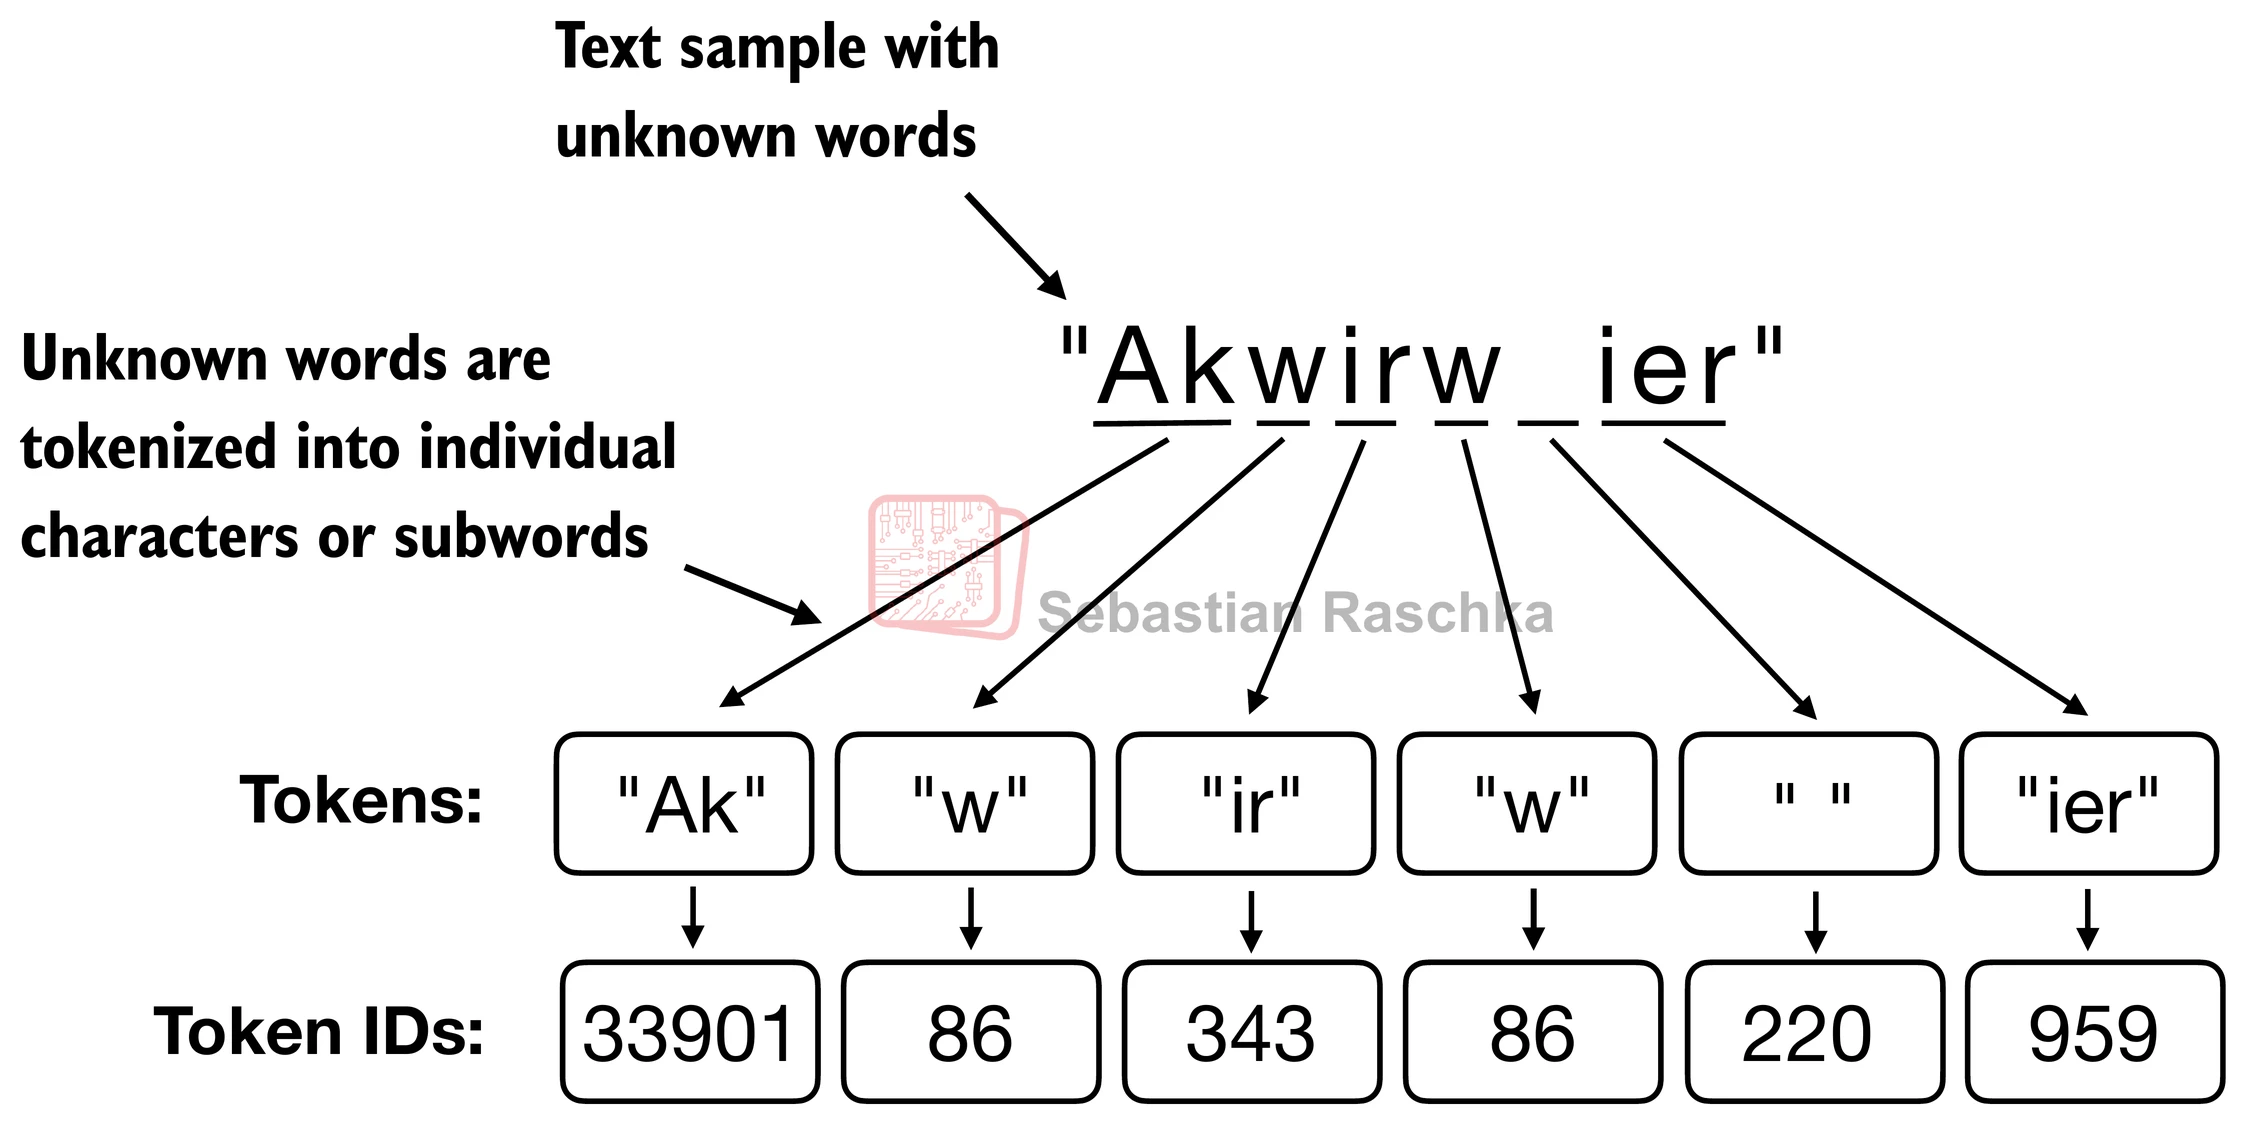